Loading: ../data/processed/new_oxphos\classical_complex_i.csv
  Complex I: 143 genes
Loading: ../data/processed/new_oxphos\classical_complex_ii.csv
  Complex II: 24 genes
Loading: ../data/processed/new_oxphos\classical_complex_iii.csv
  Complex III: 16 genes
Loading: ../data/processed/new_oxphos\classical_complex_iv.csv
  Complex IV: 52 genes
Loading: ../data/processed/new_oxphos\classical_complex_v.csv
  Complex V: 26 genes

Genes to plot:
Complex I: 143 genes
Complex II: 24 genes
Complex III: 16 genes
Complex IV: 52 genes
Complex V: 26 genes


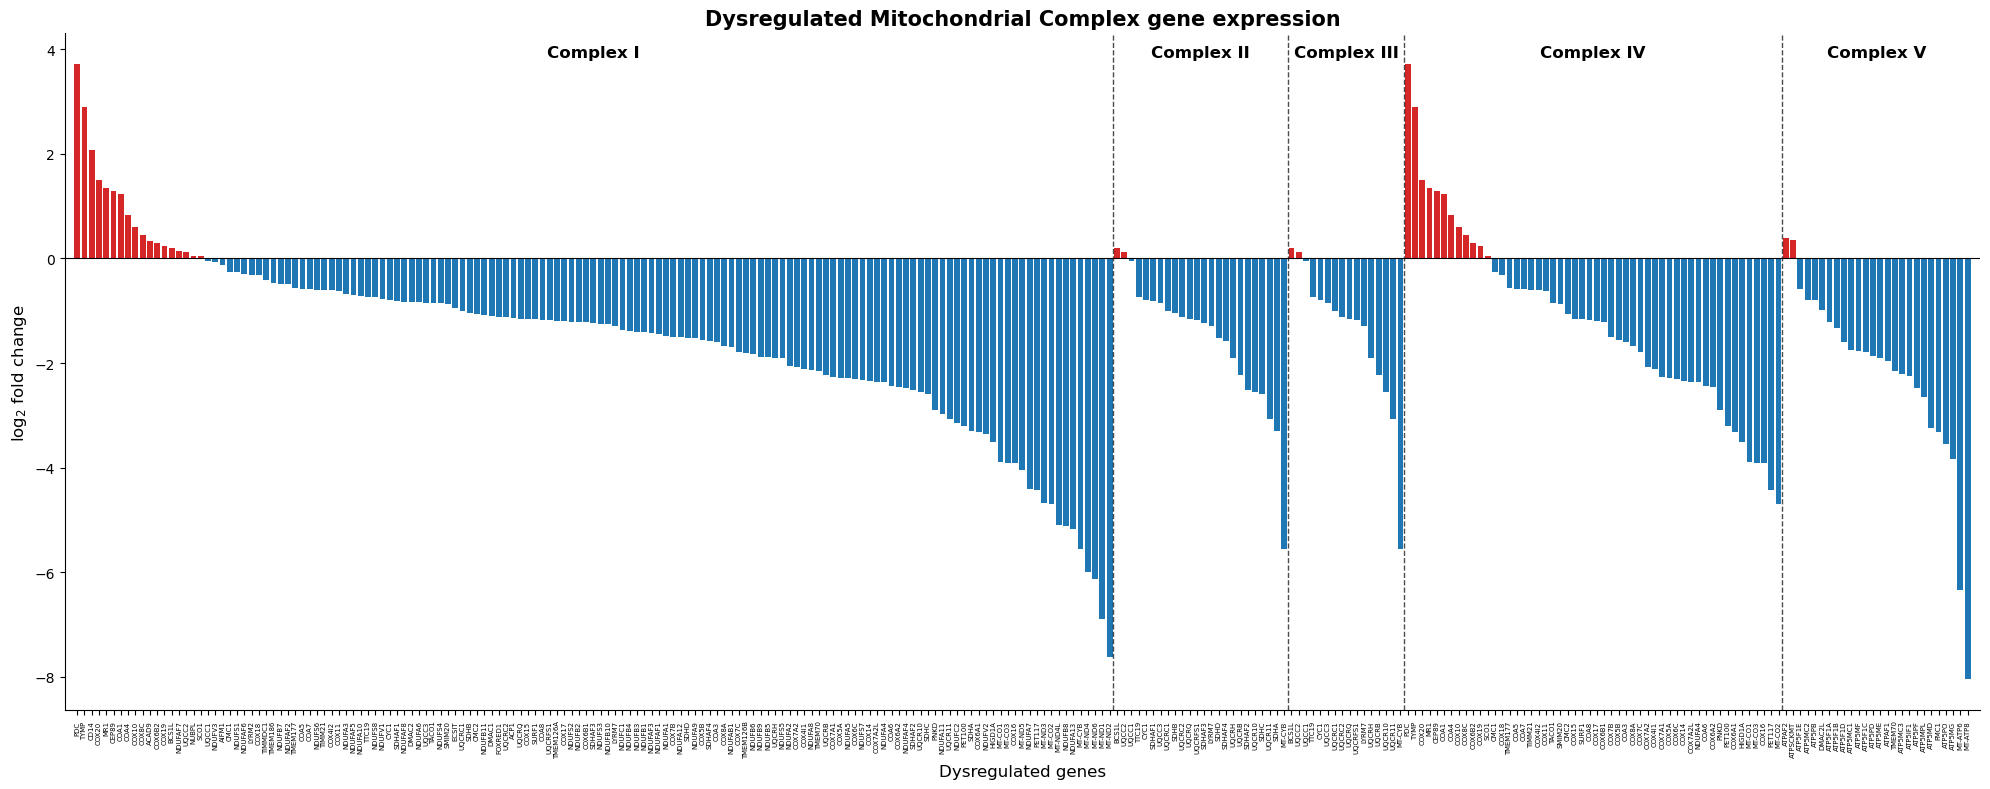


Saved: ../data/interim/network_stat/classical/classical_mitochondrial_complexes_log2fc.svg


In [ ]:
import os

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

subtype = "classical"

OXPHOS_DIR = "../data/processed/new_oxphos"

complexes = [
    "complex_i",
    "complex_ii",
    "complex_iii",
    "complex_iv",
    "complex_v"
]

complex_labels = {
    "complex_i": "Complex I",
    "complex_ii": "Complex II",
    "complex_iii": "Complex III",
    "complex_iv": "Complex IV",
    "complex_v": "Complex V"
}


# ============================================================
# LOAD COMPLEX DIFFERENTIAL RESULTS
# ============================================================

complex_data = {}

for complex_name in complexes:

    filepath = os.path.join(
        OXPHOS_DIR,
        f"{subtype}_{complex_name}.csv"
    )

    print(f"Loading: {filepath}")

    df = pd.read_csv(
        filepath,
        index_col=0
    )

    # Clean gene names
    df.index = (
        df.index
        .astype(str)
        .str.strip()
        .str.upper()
    )

    complex_data[complex_name] = df

    print(
        f"  {complex_labels[complex_name]}: "
        f"{len(df)} genes"
    )


# ============================================================
# COMBINE ALL COMPLEX GENES
# ============================================================

plot_data = []

for complex_name, df in complex_data.items():

    for gene, row in df.iterrows():

        if "log2FC" not in df.columns:
            raise ValueError(
                f"'log2FC' column not found in "
                f"{complex_name}"
            )

        plot_data.append({
            "gene": gene,
            "complex": complex_labels[complex_name],
            "log2FC": row["log2FC"]
        })


plot_df = pd.DataFrame(plot_data)


# ============================================================
# REMOVE DUPLICATE GENE/COMPLEX ENTRIES
# ============================================================

plot_df = (
    plot_df
    .drop_duplicates(
        subset=["gene", "complex"]
    )
    .reset_index(drop=True)
)


# ============================================================
# PRINT SUMMARY
# ============================================================

print("\nGenes to plot:")

for complex_name in complex_labels.values():

    subset = plot_df[
        plot_df["complex"] == complex_name
    ]

    print(
        f"{complex_name}: "
        f"{len(subset)} genes"
    )


# ============================================================
# ORDER GENES BY COMPLEX + MAGNITUDE WITHIN EACH COMPLEX
# ============================================================

complex_order = [
    "Complex I",
    "Complex II",
    "Complex III",
    "Complex IV",
    "Complex V"
]

plot_df["complex"] = pd.Categorical(
    plot_df["complex"],
    categories=complex_order,
    ordered=True
)

plot_df = (
    plot_df
    .sort_values(
        ["complex", "log2FC"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(20, 8)
)

x = range(len(plot_df))


# ============================================================
# COLOR BY DIRECTION OF CHANGE ONLY
# ============================================================

plot_df["color"] = plot_df["log2FC"].apply(
    lambda value: "#d62728" if value > 0 else "#1f77b4"
)

bars = ax.bar(
    x,
    plot_df["log2FC"],
    color=plot_df["color"],
    width=0.8
)


# ============================================================
# ZERO LINE
# ============================================================

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)


# ============================================================
# GENE LABELS
# ============================================================

label_fontsize = (
    10 if len(plot_df) <= 25 else
    8 if len(plot_df) <= 45 else
    6 if len(plot_df) <= 70 else
    5
)

ax.set_xticks(
    list(x)
)

ax.set_xticklabels(
    plot_df["gene"],
    rotation=90,
    fontsize=label_fontsize,
    ha="center",
    va="top"
)

ax.tick_params(axis="x", pad=4)
ax.margins(x=0.005)


# ============================================================
# COMPLEX SEPARATORS
# ============================================================

for i in range(1, len(complex_order)):

    previous_complex = complex_order[i - 1]
    current_complex = complex_order[i]

    previous_indices = plot_df.index[
        plot_df["complex"] == previous_complex
    ]

    current_indices = plot_df.index[
        plot_df["complex"] == current_complex
    ]

    if len(previous_indices) > 0 and len(current_indices) > 0:

        boundary = previous_indices.max() + 0.5

        ax.axvline(
            boundary,
            color="black",
            linestyle="--",
            linewidth=1,
            alpha=0.7
        )


# ============================================================
# COMPLEX LABELS
# ============================================================

for complex_name in complex_order:

    indices = plot_df.index[
        plot_df["complex"] == complex_name
    ]

    if len(indices) == 0:
        continue

    center = (indices.min() + indices.max()) / 2

    ax.text(
        center,
        ax.get_ylim()[1] * 0.95,
        complex_name,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold"
    )


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_ylabel(
    "log$_2$ fold change",
    fontsize=12
)

ax.set_xlabel(
    "Dysregulated genes",
    fontsize=12
)

ax.set_title(
    "Dysregulated Mitochondrial Complex gene expression",
    fontsize=15,
    fontweight="bold"
)


# ============================================================
# CLEANUP
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.subplots_adjust(
    bottom=0.28,
    top=0.90
)

plt.tight_layout()


# ============================================================
# SAVE
# ============================================================

outdir = (
    "../data/interim/"
    "network_stat/"
    f"{subtype}/"
)

os.makedirs(
    outdir,
    exist_ok=True
)

outfile = os.path.join(
    outdir,
    f"{subtype}_mitochondrial_complexes_log2fc.svg"
)

plt.savefig(
    outfile,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved: {outfile}")


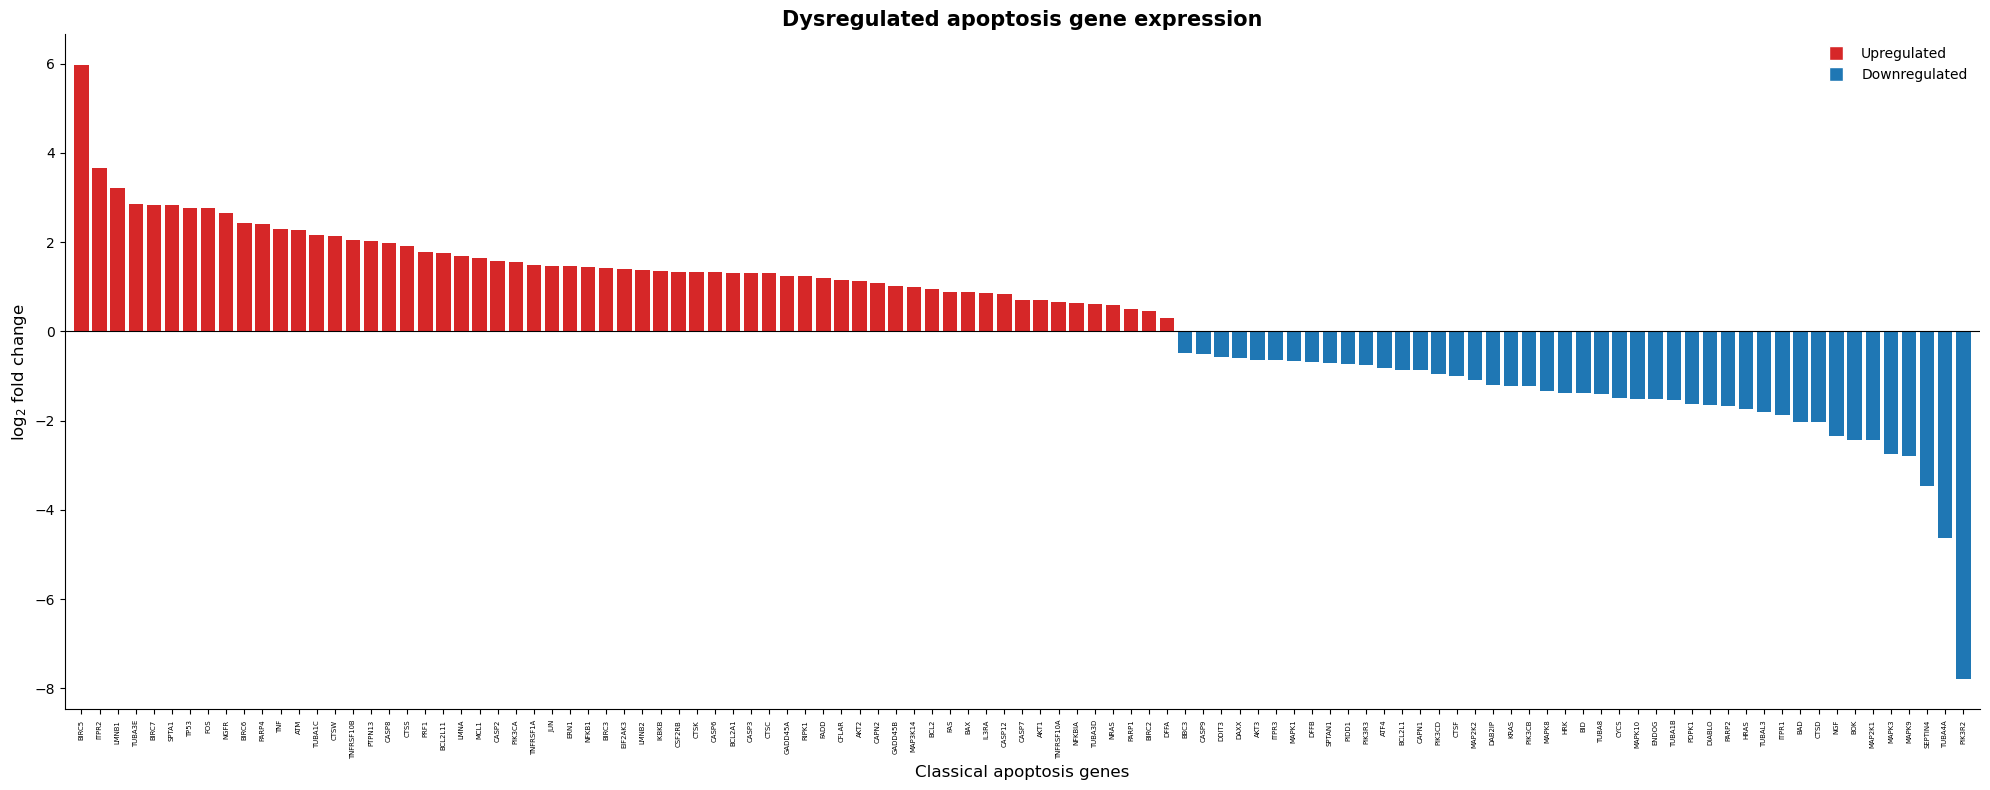

Saved: ..\data\interim\network_stat\classical\classical_apoptosis_log2fc.svg


In [5]:
import os

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

pathway_name = "classical_Apoptosis"
input_path = os.path.join(
    "..",
    "data",
    "processed",
    "new_pathway_diff",
    "classical",
    f"{pathway_name}_diff.csv"
)

outdir = os.path.join(
    "..",
    "data",
    "interim",
    "network_stat",
    "classical"
)
os.makedirs(outdir, exist_ok=True)


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(input_path, index_col=0)

df.index = (
    df.index
    .astype(str)
    .str.strip()
    .str.upper()
)

df = df[["log2FC", "category"]].copy()
df = df.dropna(subset=["log2FC"]).reset_index()

df = df.rename(columns={"index": "gene"})

# Use sign to define color, regardless of significance class.
df["color"] = df["log2FC"].apply(
    lambda value: "#d62728" if value > 0 else "#1f77b4"
)

# Sort from largest positive to largest negative effect.
df = df.sort_values(
    by="log2FC",
    ascending=False,
    kind="mergesort"
).reset_index(drop=True)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(20, 8))

x = range(len(df))

ax.bar(
    x,
    df["log2FC"],
    color=df["color"],
    width=0.8
)

ax.axhline(0, color="black", linewidth=0.8)

label_fontsize = (
    10 if len(df) <= 25 else
    8 if len(df) <= 45 else
    6 if len(df) <= 70 else
    5
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    df["gene_name"],
    rotation=90,
    fontsize=label_fontsize,
    ha="center",
    va="top"
)
ax.tick_params(axis="x", pad=4)
ax.margins(x=0.005)

ax.set_ylabel("log$_2$ fold change", fontsize=12)
ax.set_xlabel("Classical apoptosis genes", fontsize=12)
ax.set_title(
    "Dysregulated apoptosis gene expression",
    fontsize=15,
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend to make the red/blue split explicit.
legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#d62728", markersize=10, label="Upregulated"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#1f77b4", markersize=10, label="Downregulated")
]
ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper right"
)

fig.subplots_adjust(bottom=0.35, top=0.90)
plt.tight_layout()

outfile = os.path.join(
    outdir,
    "classical_apoptosis_log2fc.svg"
)
plt.savefig(outfile, format="svg", bbox_inches="tight")
plt.show()

print(f"Saved: {outfile}")
